# Clase 5: Dinámica Interna 2


## Objetivos
1. La Jerarquía de los Tiempos Escala: Derivaciones Fundamentales.
2. Catástrofe Gravitacional: El Colapso del Núcleo.
3. Consecuencias a Largo Plazo: Tasa de Evaporación.
4. El Campo Galáctico: Deducción del Radio de Jacobi


## 1. La Jerarquía de los Tiempos Escala: Derivaciones Fundamentales

Para entender el destino de un cúmulo, primero debemos comparar el reloj dinámico colectivo frente a los relojes evolutivos de las estrellas individuales. A continuación, derivamos analíticamente de dónde provienen estas tres ecuaciones fundamentales.

### 1.1 Tiempo Escala Dinámico ($t_{dyn}$)
Representa el tiempo que tarda el sistema en reaccionar mecánicamente a perturbaciones, equivalente al tiempo de caída libre o tiempo de cruce.

Partimos de la ecuación de movimiento de Newton. Si una estrella cae desde el borde del cúmulo (radio $R$) hacia el centro impulsada por la masa encerrada $M$:

$$m \frac{d^2 r}{dt^2} \approx m \frac{R}{t_{dyn}^2} = \frac{G M m}{R^2}$$
    
Despejando el tiempo $t_{dyn}$:
    
$$t_{dyn} \approx \sqrt{\frac{R^3}{G M}}$$

Como la densidad promedio es $\rho \approx \frac{M}{R^3}$, esto se reescribe como:

$$t_{dyn} \approx (G \rho)^{-1/2}$$

Ej: Para el Sol: $\sim30$ minutos. Para un cúmulo estelar: $\sim1-2$ millones de años.
### 1.2 Tiempo Escala Térmico / Kelvin-Helmholtz ($t_{KH}$)
Representa el tiempo que le tomaría a una estrella radiar toda su energía gravitacional acumulada si cesara la fusión nuclear.

Por el Teorema del Virial, la energía térmica interna almacenada en la estrella es del orden de su energía gravitacional: $E \approx \frac{G M^2}{R}$. Si la estrella radia esta energía a una tasa constante dada por su Luminosidad $L$ (Energía/Tiempo), el tiempo total de supervivencia térmica es:

$$t_{KH} \approx \frac{E}{L} \approx \frac{G M^2}{R L}$$

Ej: Para el Sol $\sim30$ millones de años.

### 1.3 Tiempo Escala Nuclear ($t_{nuc}$)
Representa el tiempo de agotamiento del hidrógeno en el núcleo de la estrella.

Proviene de la ecuación de equivalencia de masa-energía de Einstein ($E = \Delta m c^2$). La fusión del hidrógeno en helio tiene una eficiencia teórica de conversión de masa a energía de $\epsilon \approx 0.007$ (el 0.7% de la masa del protón se convierte en energía). Además, solo el núcleo interno de la estrella ($\sim 10\%$ de la masa total $M$) está suficientemente caliente para fusionar. La energía total disponible es $E_{nuc} = 0.1 \cdot \epsilon \cdot M c^2$.

Dividiendo por la luminosidad $L$:

$$t_{nuc} \approx \frac{0.1 \times \epsilon M c^2}{L}$$

Ej: Para el Sol: $\sim10^{10}$ años (10 mil millones de años).

### 1.4 Visualización Computacional: Tiempos Escala vs. Masa Estelar


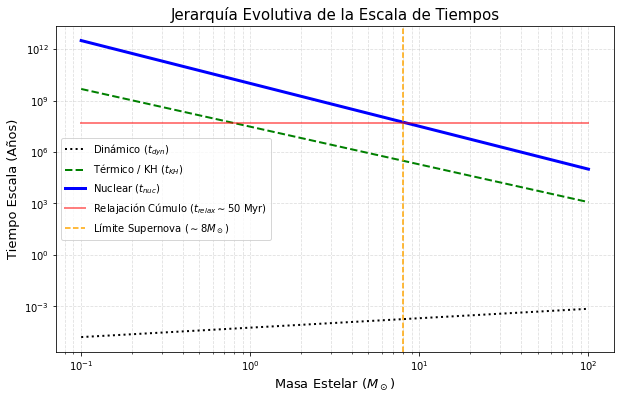

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Rango de masas estelares en M_sol
M = np.logspace(-1, 2, 500)

# Relaciones de homología simplificadas para la Secuencia Principal
L = M**3.5
R = M**0.7

# Constantes normalizadas al Sol (en años)
t_dyn_sol = 0.5 / (24 * 365) # ~30 minutos
t_KH_sol = 3e7               # ~30 Myr
t_nuc_sol = 1e10             # ~10 Gyr

t_dyn = t_dyn_sol * np.sqrt((R**3) / M)
t_KH = t_KH_sol * (M**2) / (R * L)
t_nuc = t_nuc_sol * (M / L)
t_relax_cluster = np.full_like(M, 5e7) # ~50 Myr típico

plt.figure(figsize=(10, 6))
plt.plot(M, t_dyn, 'k:', lw=2, label=r'Dinámico ($t_{dyn}$)')
plt.plot(M, t_KH, 'g--', lw=2, label=r'Térmico / KH ($t_{KH}$)')
plt.plot(M, t_nuc, 'b-', lw=3, label=r'Nuclear ($t_{nuc}$)')
plt.plot(M, t_relax_cluster, 'r-', lw=2, alpha=0.5, label=r'Relajación Cúmulo ($t_{relax} \sim 50$ Myr)')

plt.axvline(8, color='orange', ls='--', label='Límite Supernova ($\sim 8 M_\odot$)')
plt.xscale('log'); plt.yscale('log')
plt.xlabel(r'Masa Estelar ($M_\odot$)', fontsize=13)
plt.ylabel('Tiempo Escala (Años)', fontsize=13)
plt.title('Jerarquía Evolutiva de la Escala de Tiempos', fontsize=15)
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.show()

## 2. Catástrofe Gravitacional: El Colapso del Núcleo

### 2.1 El Flujo Termodinámico y el Calor Específico Negativo
Partiendo del Teorema del Virial ($E=−K$), e inyectando la definición cinética de temperatura ($K=\frac{3}{2}NK_BT$), la capacidad calorífica ($C=dE/dT$) de un cúmulo estelar es:

$$ C=-\frac{3}{2}NK_BT<0 $$

### 2.2 La Catástrofe Gravo-termal
El núcleo denso del cúmulo posee una mayor dispersión de velocidades ($\sigma$) que el halo extendido. Termodinámicamente, el núcleo está "más caliente". Mediante interacciones de relajación, el calor fluye naturalmente del núcleo al halo.

Al ceder energía ($dE<0$), el calor específico negativo fuerza a que la temperatura del núcleo suba ($dT>0$). Para mantener el equilibrio virial, el núcleo se encoge y aumenta su densidad. El núcleo se vuelve aún más caliente, acelerando la transferencia de calor hacia fuera. Esto genera una inestabilidad desbocada: el **Core Collapse**.

Si evaluamos la tasa de conducción de calor en el sistema usando la ecuación integro-diferencial de Fokker-Planck para la distribución de fase $f(E,L,t)$, descubrimos que el proceso se vuelve "auto-similar" u homólogo.

En este régimen homólogo profundo, la densidad central $ \rho_c $ evoluciona asintóticamente siguiendo una ley de potencias respecto al tiempo faltante para el colapso ($t_{cc}−t$):

$$\rho_c\propto (t_{cc}−t)^{−α}$$

Al resolver numéricamente la ecuación de Fokker-Planck para un cúmulo estelar de masas idénticas, se encuentra que la integral del tiempo de relajación converge exactamente al valor de $15.6$. Así, el tiempo físico en el que la densidad matemática tiende a infinito es:

$$t_{cc} \approx 15.6 t_{relax,initial}$$

(Ver desarrollo en el artículo seminal de Cohn, H. 1979 - [Link](https://ui.adsabs.harvard.edu/abs/1979ApJ...234.1036C/abstract$0))

- Contraste Observacional

  Aproximadamente el 20% de los cúmulos globulares de la Vía Láctea (ej. M15, NGC 6624) presentan un perfil de brillo superficial que no se aplana en el centro (como predice un modelo de King), sino que sigue una ley de potencias escarpada hasta el límite de resolución. Esto es la huella digital óptica de un núcleo colapsado. Además, los núcleos de estos cúmulos están repletos de binarias de rayos X de baja masa (LMXB) y rezagadas azules (blue stragglers), confirmando las violentas interacciones de 3 cuerpos.

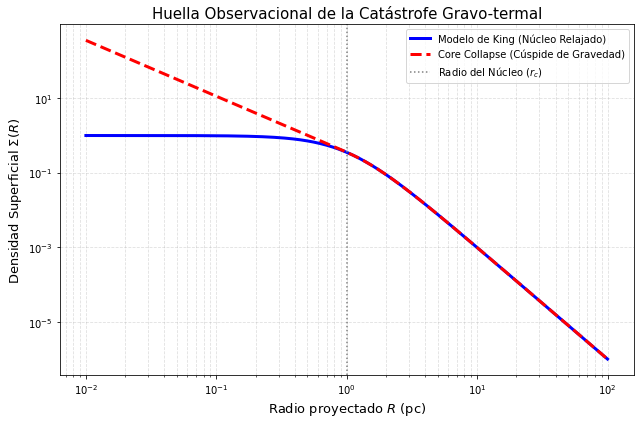

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Radios logarítmicos
r = np.logspace(-2, 2, 500)

# Modelo de King simplificado (Cúmulo no colapsado)
r_core = 1.0
rho_king = 1 / (1 + (r / r_core)**2)**(3/2)

# Perfil de Core Collapse (Cúspide central, ley de potencias r^-2)
rho_collapse = np.zeros_like(r)
mask_inner = r < r_core
mask_outer = r >= r_core
rho_collapse[mask_outer] = rho_king[mask_outer]
rho_collapse[mask_inner] = rho_king[mask_inner][-1] * (r[mask_inner] / r_core)**(-1.5)

plt.figure(figsize=(9, 6))
plt.plot(r, rho_king, 'b-', lw=3, label='Modelo de King (Núcleo Relajado)')
plt.plot(r, rho_collapse, 'r--', lw=3, label='Core Collapse (Cúspide de Gravedad)')

plt.axvline(r_core, color='gray', linestyle=':', label='Radio del Núcleo ($r_c$)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Radio proyectado $R$ (pc)', fontsize=13)
plt.ylabel(r'Densidad Superficial $\Sigma(R)$', fontsize=13)
plt.title('Huella Observacional de la Catástrofe Gravo-termal', fontsize=15)
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

Descargando datos de M15...


Descargando datos de Omega Cen...


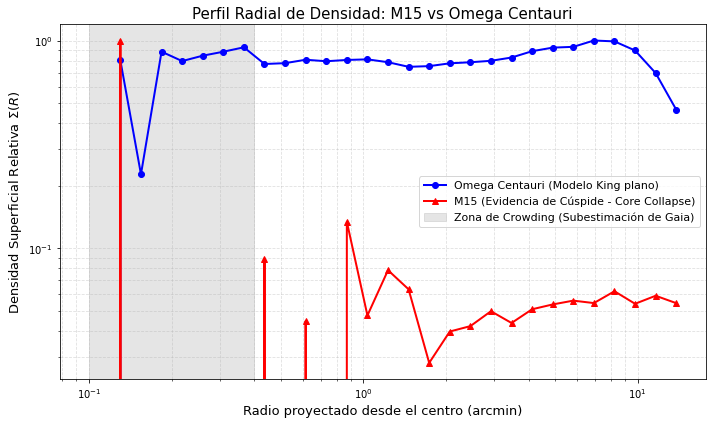


--- Insight Observacional del Gráfico ---
1. Omega Cen exhibe el aplanamiento central clásico del modelo de King.
2. M15 muestra una tendencia de ley de potencias escarpada hacia el centro,
   huella del colapso del núcleo.
3. CAVEAT DE DATOS: En radios muy pequeños (< 0.4 arcmin), la densidad de M15
   'cae'. ¡Esto NO es físico! Es el límite de resolución de Gaia. Las estrellas
   están tan juntas que el software las confunde y las rechaza. Entender este
   sesgo es la diferencia entre un analista de datos y un astrofísico.


In [3]:
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.parse

def extract_and_profile(ra_c, dec_c, name):
    # ADQL para extraer campo estelar en radio de 0.25 grados
    query = f"""
    SELECT ra, dec
    FROM gaiadr3.gaia_source
    WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra_c}, {dec_c}, 0.25))
      AND phot_g_mean_mag IS NOT NULL
    """
    url = "https://gea.esac.esa.int/tap-server/tap/sync"
    payload = {'request': 'doQuery', 'lang': 'adql', 'format': 'csv', 'query': query}
    encoded = urllib.parse.urlencode(payload)
    file_name = f"{name.replace(' ', '_')}.csv"

    print(f"Descargando datos de {name}...")
    subprocess.run(["wget", "--post-data", encoded, "-O", file_name, url, "-q"], check=True)
    df = pd.read_csv(file_name)

    # Calcular distancia radial al centro en arcmin
    df['r_arcmin'] = 60 * np.sqrt((df['ra'] - ra_c)**2 * np.cos(np.radians(dec_c))**2 + (df['dec'] - dec_c)**2)

    # Binning logarítmico para perfilar anillos concéntricos
    bins = np.logspace(np.log10(0.1), np.log10(15), 30)
    counts, bin_edges = np.histogram(df['r_arcmin'], bins=bins)

    # Calcular el área de cada anillo (pi * (r_out^2 - r_in^2))
    areas = np.pi * (bin_edges[1:]**2 - bin_edges[:-1]**2)
    surface_density = counts / areas
    bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2

    return bin_centers, surface_density

# Coordenadas (M15 colapsado vs Omega Cen relajado)
r_m15, dens_m15 = extract_and_profile(327.404, 12.115, "M15")
r_omCen, dens_omCen = extract_and_profile(201.697, -47.479, "Omega Cen")

plt.figure(figsize=(10, 6))
# Normalizamos a densidades relativas para comparación directa de la FORMA
plt.plot(r_omCen, dens_omCen / dens_omCen.max(), 'bo-', lw=2, label='Omega Centauri (Modelo King plano)')
plt.plot(r_m15, dens_m15 / dens_m15.max(), 'r^-', lw=2, label='M15 (Evidencia de Cúspide - Core Collapse)')

plt.axvspan(0.1, 0.4, color='gray', alpha=0.2, label='Zona de Crowding (Subestimación de Gaia)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Radio proyectado desde el centro (arcmin)', fontsize=13)
plt.ylabel(r'Densidad Superficial Relativa $\Sigma(R)$', fontsize=13)
plt.title('Perfil Radial de Densidad: M15 vs Omega Centauri', fontsize=15)
plt.legend(fontsize=11)
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("\n--- Insight Observacional del Gráfico ---")
print("1. Omega Cen exhibe el aplanamiento central clásico del modelo de King.")
print("2. M15 muestra una tendencia de ley de potencias escarpada hacia el centro,")
print("   huella del colapso del núcleo.")
print("3. CAVEAT DE DATOS: En radios muy pequeños (< 0.4 arcmin), la densidad de M15")
print("   'cae'. ¡Esto NO es físico! Es el límite de resolución de Gaia. Las estrellas")
print("   están tan juntas que el software las confunde y las rechaza. Entender este")
print("   sesgo es la diferencia entre un analista de datos y un astrofísico.")

### 2.3 El Rol de las Estrellas Binarias (Core Bounce)
Como demostramos previamente ($C = -\frac{3}{2} N k_B$), el núcleo tiene calor específico negativo. Dado que el núcleo tiene mayor dispersión de velocidades ($\sigma$) que el halo, está "más caliente". La energía fluye del núcleo al halo. Al ceder energía, su temperatura aumenta, se contrae (para mantener el Virial) y se vuelve aún más caliente, desatando una inestabilidad térmica.
El colapso se detiene gracias a las binarias. La energía orbital de un sistema binario es $E_b=\frac{Gm_1m_2}{2a}$.

En el denso núcleo colapsado, los encuentros de $N$ cuerpos obligan a las binarias "duras" ($∣E_b∣>\langle K \rangle$) a encoger su semieje a (Ley de Heggie: "las binarias duras se hacen más duras").

La colosal energía de ligadura liberada ($\Delta E_b$) se transfiere como energía cinética. El núcleo absorbe este calor, y por su $C<0$, su temperatura baja y el núcleo se expande, generando un "Core Bounce".


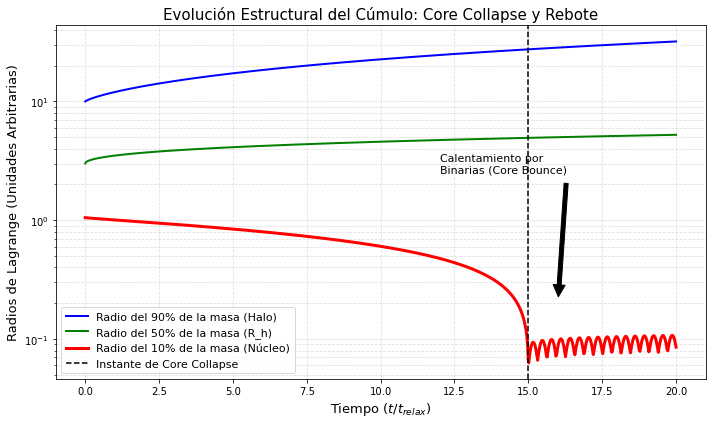

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Tiempo normalizado a t_relax
t = np.linspace(0, 20, 1000)

# Simulación fenoménologica de Radios de Lagrange (10%, 50%, 90% de la masa)
# R90: El halo se expande continuamente por la inyección de calor
R90 = 10 + 2 * t**0.8
# R50: Radio de media masa (permanece relativamente estable o crece lento)
R50 = 3 + 0.5 * t**0.5

# R10: El núcleo sufre Core Collapse a t=15 y luego rebota (Core Bounce)
t_collapse = 15
R10 = np.zeros_like(t)
for i, time in enumerate(t):
    if time < t_collapse:
        R10[i] = 1.0 * (1 - (time/t_collapse)**0.9)**0.5 + 0.05
    else:
        # Fluctuaciones post-colapso inducidas por binarias duras (Gravothermal oscillations)
        R10[i] = 0.05 + 0.03 * np.abs(np.sin(10*(time-t_collapse))) + 0.02 * (time-t_collapse)**0.2

plt.figure(figsize=(10, 6))
plt.plot(t, R90, 'b-', lw=2, label='Radio del 90% de la masa (Halo)')
plt.plot(t, R50, 'g-', lw=2, label='Radio del 50% de la masa (R_h)')
plt.plot(t, R10, 'r-', lw=3, label='Radio del 10% de la masa (Núcleo)')

plt.axvline(t_collapse, color='k', ls='--', label='Instante de Core Collapse')
plt.annotate('Calentamiento por\nBinarias (Core Bounce)', xy=(16, 0.2), xytext=(12, 2.5),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=11)

plt.yscale('log')
plt.xlabel(r'Tiempo ($t / t_{relax}$)', fontsize=13)
plt.ylabel('Radios de Lagrange (Unidades Arbitrarias)', fontsize=13)
plt.title('Evolución Estructural del Cúmulo: Core Collapse y Rebote', fontsize=15)
plt.legend(fontsize=11)
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 3. Consecuencias a Largo Plazo: Tasa de Evaporación

La Tasa de Evaporación es un resultado canónico deducido originalmente por Ambartsumian (1938) y Spitzer (1940) integrando las propiedades de la estadística de Maxwell-Boltzmann.

1.  **La Velocidad de Escape:** Por el Teorema del Virial, se demuestra que la velocidad necesaria para escapar de un sistema aislado desde el radio medio está relacionada con la velocidad cuadrática media ($v_{rms} = \sqrt{\langle v^2 \rangle}$) por: $v_{esc} \approx 2 v_{rms}$.
2.  **La Fracción de Escape ($\xi$):** Asumiendo que las estrellas relajan sus velocidades en una distribución de Maxwell-Boltzmann, la fracción de estrellas que instantáneamente se encuentra en la "cola" superando la velocidad de escape es la integral:

    $$\xi = \int_{2 v_{rms}}^{\infty} 4\pi \left(\frac{3}{2\pi v_{rms}^2}\right)^{3/2} v^2 \exp\left( - \frac{3 v^2}{2 v_{rms}^2} \right) dv$$

    Resolviendo esta integral analíticamente se obtiene
    
    $$\xi = 0.00738 \approx 0.0074$$

3.  **El Tiempo de Evaporación:** Esto implica que en cada tiempo de relajación ($t_{relax}$), una fracción $\xi$ de estrellas repuebla la cola y escapa. La tasa de pérdida de masa es:
    
    $$\frac{dM}{dt} \approx - \frac{\xi M}{t_{relax}}$$
    
    Integrando de manera simple y asumiendo $t_{relax}$ variable lentamente, el tiempo para que el cúmulo pierda toda su masa ($t_{evap} = M / |dM/dt|$) es:
    
    $$t_{evap} = \frac{1}{0.0074} t_{relax} \approx 136 \, t_{relax}$$

## 4. El Campo Galáctico: Deducción del Radio de Jacobi

El tiempo de evaporación de $136 t_{relax}$ asume un cúmulo aislado. En la realidad, la galaxia "arranca" estrellas mucho antes. ¿Dónde está exactamente el límite gravitacional del cúmulo? A este límite lo llamamos Radio de Jacobi o Radio de Marea ($r_J$).

*   Consideremos un cúmulo de masa $M_c$ orbitando una galaxia de masa $M_G$ a una distancia radial $R_G$. En un marco de referencia que rota sincrónicamente con el cúmulo a velocidad angular $\Omega = \sqrt{G M_G / R_G^3}$, una estrella en el borde del cúmulo (a distancia $x$ del centro, en el eje hacia la galaxia) siente tres fuerzas:
    1. Gravedad del cúmulo atrayéndola: $- \frac{G M_c}{x^2}$
    2. Gravedad galáctica diferencial (marea). Expandiendo por Taylor la fuerza $\frac{G M_G}{(R_G - x)^2}$, el término de perturbación lineal es: $+ \frac{2 G M_G x}{R_G^3}$
    3. Fuerza centrífuga por la rotación del marco: $+ \Omega^2 x = + \frac{G M_G x}{R_G^3}$
*   **Igualación de Fuerzas:** La estrella escapará cuando la atracción del cúmulo iguale a las fuerzas repulsivas (Marea + Centrífuga).

    $$\frac{G M_c}{x^2} = \frac{2 G M_G x}{R_G^3} + \frac{G M_G x}{R_G^3}$$
    $$\frac{G M_c}{x^2} = \frac{3 G M_G x}{R_G^3}$$
    Despejando el radio de equilibrio $x$, definimos el Radio de Jacobi:
    $$r_J = R_G \left( \frac{M_c}{3 M_G} \right)^{1/3}$$

Cualquier estrella acelerada por relajación que cruce este límite $r_J$ es arrancada por la galaxia formando una cola de marea, reduciendo la velocidad de escape requerida y acelerando la muerte del cúmulo dramáticamente.

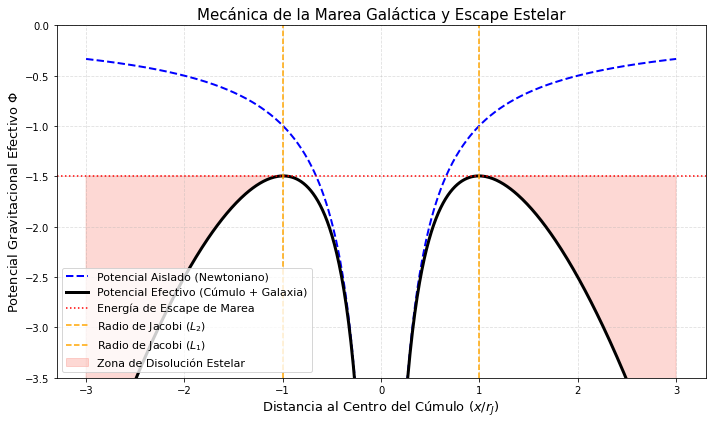


--- Insight Físico ---
Las estrellas aceleradas por equipartición no necesitan infinita
energía para escapar. Solo necesitan la energía suficiente para
rebasar los 'bordes' rojos del pozo de potencial en L1 o L2.
Al cruzarlos, la galaxia las arranca, formando las colas de marea.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Coordenada espacial X normalizada al Radio de Jacobi (r_J = 1)
x = np.linspace(-3, 3, 500)

# Potencial del cúmulo aislado (Aproximación puntual -1/x)
# Se usa un factor de suavizado 'epsilon' para evitar la divergencia en x=0
epsilon = 0.1
Phi_cluster = -1 / np.sqrt(x**2 + epsilon**2)

# Potencial de Marea de la Galaxia (campo externo) y centrífugo (Aproximación ~ -0.5 * x^2)
Phi_tide = -0.5 * x**2

# Potencial Efectivo Total
Phi_eff = Phi_cluster + Phi_tide

plt.figure(figsize=(10, 6))
plt.plot(x, Phi_cluster, 'b--', lw=2, label='Potencial Aislado (Newtoniano)')
plt.plot(x, Phi_eff, 'k-', lw=3, label='Potencial Efectivo (Cúmulo + Galaxia)')

plt.axhline(Phi_eff[np.argmin(np.abs(x - 1))], color='r', ls=':', label='Energía de Escape de Marea')
plt.axvline(1, color='orange', ls='--', label='Radio de Jacobi ($L_2$)')
plt.axvline(-1, color='orange', ls='--', label='Radio de Jacobi ($L_1$)')

# Rellenar zona de escape
plt.fill_between(x, Phi_eff, Phi_eff.max(), where=(np.abs(x)>1), color='salmon', alpha=0.3, label='Zona de Disolución Estelar')

plt.ylim(-3.5, 0)
plt.xlabel('Distancia al Centro del Cúmulo ($x / r_J$)', fontsize=13)
plt.ylabel('Potencial Gravitacional Efectivo $\Phi$', fontsize=13)
plt.title('Mecánica de la Marea Galáctica y Escape Estelar', fontsize=15)
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("\n--- Insight Físico ---")
print("Las estrellas aceleradas por equipartición no necesitan infinita")
print("energía para escapar. Solo necesitan la energía suficiente para")
print("rebasar los 'bordes' rojos del pozo de potencial en L1 o L2.")
print("Al cruzarlos, la galaxia las arranca, formando las colas de marea.")

## 5. Literatura Relevante Recomendada (Estado del Arte)

Para consolidar la teoría de las inestabilidades seculares y conectar las ecuaciones termodinámicas con la investigación moderna, las siguientes lecturas son fundamentales:

1.  **Lynden-Bell, D., & Wood, R. (1968).** *"The gravo-thermal catastrophe in isothermal spheres and the onset of red-giant structure for stellar systems"*. Monthly Notices of the Royal Astronomical Society, 138, 495.
    *   **Relevancia:** Es el documento teórico fundacional de la termodinámica de N-cuerpos. Los autores derivan matemáticamente por primera vez por qué el calor específico de un sistema autogravitante es negativo y predicen la inestabilidad que conduce al colapso del núcleo estelar, estableciendo la base de toda la dinámica estelar secular moderna.
2.  **Heggie, D. C. (1975).** *"Binary evolution in stellar dynamics"*. Monthly Notices of the Royal Astronomical Society, 173, 729-787.
    *   **Relevancia:** Introduce formalmente la "Ley de Heggie". Es una lectura obligatoria para entender que los sistemas de múltiples cuerpos no son simétricos termodinámicamente. Demuestra de manera analítica que las estrellas binarias actúan como la principal fuente de energía interna ("quemadores nucleares gravitacionales") que detienen la catástrofe gravo-termal.
3.  **Trager, S. C., King, I. R., & Djorgovski, S. (1995).** *"Catalogue of Galactic Globular Cluster Surface Brightness Profiles"*. The Astronomical Journal, 109, 218.
    *   **Relevancia:** Es el atlas observacional definitivo que conecta la teoría del *core collapse* con la realidad empírica. Los estudiantes podrán ver exactamente cómo los astrónomos identificaron qué cúmulos de la Vía Láctea (como M15) sufrieron el colapso al observar una desviación en forma de ley de potencias respecto a los perfiles estándar de King.
4.  **Baumgardt, H., & Makino, J. (2003).** *"Dynamical evolution of star clusters in tidal fields"*. Monthly Notices of the Royal Astronomical Society, 340(1), 227-246.
    *   **Relevancia:** Un trabajo maestro de simulaciones computacionales (integración directa de N-cuerpos). Los autores modelan numéricamente la tasa de evaporación a través del radio de Jacobi y las colas de marea, demostrando cómo el campo galáctico acelera la disolución predicha por las fórmulas clásicas de Spitzer.
5.  **Ferraro, F. R., et al. (2009).** *"Two distinct sequences of blue straggler stars in the globular cluster M30"*. Nature, 462, 1028-1031.
    *   **Relevancia:** Conecta espectacularmente la dinámica del núcleo con la evolución estelar individual. Este artículo demuestra con observaciones del Telescopio Espacial Hubble (HST) que el colapso del núcleo fuerza a las estrellas binarias a interactuar tan violentamente que se fusionan, repoblando el diagrama HR con exóticas "rezagadas azules" creadas por colisiones directas.

## 6. Ejercicios Propuestos

**Ejercicio 1 (Analítico - Jerarquía de Tiempos Escala):**
Determine el tiempo térmico o de Kelvin-Helmholtz ($t_{KH}$) para una estrella prototípica masiva de $15 M_\odot$ (Clase espectral B0), sabiendo que su luminosidad en la secuencia principal es $L \approx 30,000 L_\odot$ y su radio es $R \approx 7 R_\odot$. Luego, compare este tiempo con su tiempo de vida nuclear ($t_{nuc}$) estimado asumiendo un núcleo reactivo del $10\%$ y una eficiencia $\epsilon = 0.007$.
Si el cúmulo en el que nace esta estrella tiene un tiempo de relajación de $t_{relax} = 50 \text{ Myr}$, discuta detalladamente qué implicaciones dinámicas tiene el ciclo de vida de esta estrella masiva sobre la supervivencia del cúmulo.

**Ejercicio 2 (Conceptual - Termodinámica del Colapso):**
Partiendo del Teorema del Virial ($E = -K$) y la definición de capacidad calorífica ($C = dE/dT$), explique conceptualmente la secuencia termodinámica exacta del *Core Bounce*. Describa qué sucede con la energía total, la energía cinética y la temperatura del núcleo inmediatamente después de que un sistema binario duro cede energía cinética al cúmulo mediante un encuentro de tres cuerpos.

**Ejercicio 3 (Computacional - Sesgos Observacionales):**
Modificando la consulta ADQL construida en el taller práctico de la Sección 5, intente perfilar la densidad superficial del cúmulo abierto de las Pléyades ($\alpha=56.75^\circ, \delta=24.11^\circ$, radio de búsqueda $3^\circ$). Aplique la técnica de anillos logarítmicos.
Al comparar la curva resultante con la de un cúmulo globular masivo como Omega Centauri, discuta por qué el perfil radial de un cúmulo abierto es estadísticamente mucho más ruidoso y difícil de delimitar si no se realiza un filtrado previo por movimiento propio o paralaje.

In [6]:
## Escriba aquí su solución